# Simulation numérique – Modèle d'Ising 2D
Notebook généré automatiquement à partir d'un script Python.

Ce notebook contient :
- Implémentation du modèle d'Ising
- Algorithme de Metropolis
- Mesures Monte‑Carlo
- Finite Size Scaling
- Algorithme de Wolff (cluster)


## Import des bibliothèques

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import deque
import time

## Classe du modèle d'Ising

In [3]:
class Modele_Ising:
    def __init__(self, taille, energie_interaction, champ):
        self.N = taille
        self.model = np.random.choice([-1, 1], size=(self.N, self.N))
        self.J = energie_interaction
        self.h = champ
        self.m = np.sum(self.model)
        self.E = self.Energie()

    def Energie(self):

        s = self.model

        voisins = (
            np.roll(s,1,axis=0) +
            np.roll(s,-1,axis=0) +
            np.roll(s,1,axis=1) +
            np.roll(s,-1,axis=1)
        )

        E_interaction = -self.J * np.sum(s * voisins) / 2
        E_champ = -self.h * np.sum(s)
        self.E = E_interaction + E_champ
        return self.E

    def plot(self):
        plt.imshow(self.model, cmap='coolwarm')
        plt.colorbar()
        plt.show()

    def magnetisation(self):
        return self.m/(self.N**2)

    def Metropolis(self, beta):
        i = np.random.randint(0, self.N)
        j = np.random.randint(0, self.N)

        s = self.model[i][j]
        voisins = (
            self.model[(i+1)%self.N, j] +
            self.model[(i-1)%self.N, j] +
            self.model[i, (j+1)%self.N] +
            self.model[i, (j-1)%self.N]
        )

        diffE = 2 * s * (self.J * voisins + self.h)

        if diffE < 0:
            self.m -= 2*self.model[i, j]
            self.E += diffE
            self.model[i, j] *= -1
        else:
            R = np.exp(-beta * diffE)
            p = np.random.uniform(0.0, 1.0)

            if p <= R:
                self.m -= 2*self.model[i, j]
                self.E += diffE
                self.model[i, j] *= -1


## Animation de la simulation (Gemini)

In [4]:
def lancer_animation(sim, beta=0.5, etapes=100000):
    plt.ion()
    fig, ax = plt.subplots()

    img = ax.imshow(sim.model, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(img)
    plt.title(f"Ising 2D - Beta: {beta}")

    for k in range(etapes):
        sim.Metropolis(beta)

        if k % 1000 == 0:
            img.set_data(sim.model)
            ax.set_title(f"Ising 2D - Beta: {beta} - Étape: {k}")
            plt.draw()
            plt.pause(0.001)

    plt.ioff()
    plt.show()


## Exemple : lancer une simulation

In [ ]:
sim = Modele_Ising(taille=100, energie_interaction=1, champ=0)
lancer_animation(sim, beta=0.25, etapes=500000)

Mesure de grandeurs physique : Méthode Monte Carlo

In [5]:
def thermalisation (modele,beta):
    for i in range (10000*(modele.N**2)):
        modele.Metropolis(beta)

def mesures_MC(modele,beta,pas, nb_mesures): # Mesures de grandeurs par la méthodes de Monte-Carlo
    E = np.zeros(nb_mesures) # mesures d'énergie
    M = np.zeros(nb_mesures) # mesures d'aimantation

    thermalisation (modele, beta)

    for i in range(nb_mesures):
        for _ in range(pas):
            modele.Metropolis(beta)
        E[i]=modele.E
        M[i]=modele.m

    E_mesure = np.mean(E)
    M_mesure = np.mean (M/modele.N**2)
    Msquare  = np.mean ((M/modele.N**2)**2)
    Mabs     = np.mean (np.abs(M)/modele.N**2)

    Esquare  = np.mean (E**2)
    return E_mesure, M_mesure, Esquare, Msquare, Mabs


def evolution_thermique(taille,pas,nb_mesures, T_i, T_f, pas_T):
    T           = np.arange(T_f,T_i,pas_T)
    E_mes       = np.zeros(len(T))
    M_mes       = np.zeros(len(T))
    Esquare_mes = np.zeros(len(T))
    Msquare_mes = np.zeros(len(T))
    Mabs_mes    = np.zeros(len(T))
    modele      = Modele_Ising(taille,
energie_interaction=1, champ=0)


    for i in tqdm(range(len(T))):
        beta= 1/T[i]
        E_mes[i],M_mes[i],Esquare_mes[i],Msquare_mes[i],Mabs_mes[i]= mesures_MC(modele,beta,pas,nb_mesures)

    return E_mes, M_mes, Esquare_mes, Msquare_mes,Mabs_mes

Finite Scale Sizing

In [6]:
Tc_exact = 2 / np.log(1 + np.sqrt(2))

def susceptibilite(beta, N, Msquare, Mabs):
    return beta * N**2 * (Msquare - Mabs**2)

def capacite_calorifique(beta, N, Esquare, Emean):
    return (beta**2 / N**2) * (Esquare - Emean**2)


def finite_size_scaling(L_list, nb_mesures):

    M_tc = []
    Chi_tc = []
    C_tc = []

    for L in tqdm(L_list):

        modele = Modele_Ising(L, energie_interaction=1, champ=0)
        beta = 1 / Tc_exact
        pas = 10*(L**2)

        E, M, Esq, Msq, Mabs = mesures_MC(modele, beta, pas, nb_mesures)

        chi = susceptibilite(beta, L, Msq, Mabs)
        C = capacite_calorifique(beta, L, Esq, E)

        M_tc.append(Mabs)
        Chi_tc.append(chi)
        C_tc.append(C)

    return np.array(M_tc), np.array(Chi_tc), np.array(C_tc)

def fit_exposant(L_list, observable):

    logL = np.log(L_list)
    logObs = np.log(observable)

    coeffs = np.polyfit(logL, logObs, 1)
    pente = coeffs[0]

    return pente



Test
---


In [ ]:
# Tailles système
L_list = np.array([4,8,16, 24, 32, 48, 64])

M_tc, Chi_tc, C_tc = finite_size_scaling(L_list,nb_mesures=2000)

## Extraction exposants

In [ ]:
beta_sur_nu = -fit_exposant(L_list, M_tc)
gamma_sur_nu = fit_exposant(L_list, Chi_tc)

print("β/ν =", beta_sur_nu)
print("γ/ν =", gamma_sur_nu)

plt.figure()
plt.loglog(L_list, M_tc, 'o-', label="Magnetisation")
plt.loglog(L_list, Chi_tc, 's-', label="Susceptibilité")
plt.xlabel("L")
plt.legend()
plt.show()


# Algorithmes par amas

## Algorithme de Wolff

In [7]:
from collections import deque

def voisins (i,j, modele):
    return [((i+1)%modele.N, j),((i-1)%modele.N, j),(i, (j+1)%modele.N),(i, (j-1)%modele.N)]


def Wolff_algo_etape(modele, beta):

    # 1. Choisir une graine au hasard
    i_start = np.random.randint(0, modele.N)
    j_start = np.random.randint(0, modele.N)
    signe_cible = modele.model[i_start, j_start]

    proba = 1 - np.exp(-2 * modele.J * beta)

    # 2. Initialiser la file et le cluster
    a_visiter = deque([(i_start, j_start)])
    cluster = {(i_start, j_start)}

    while a_visiter:
        i, j = a_visiter.popleft()

        for u, v in voisins(i, j, modele):
            # CONDITION : même signe ET pas encore dans le cluster
            if modele.model[u, v] == signe_cible:
                if (u, v) not in cluster:
                    if np.random.rand() < proba:
                        a_visiter.append((u, v))
                        cluster.add((u, v))

    # 3. Retournement et mise à jour de la magnétisation
    taille_cluster = len(cluster)
    modele.m -= 2 * taille_cluster * signe_cible

    for (u, v) in cluster:
        modele.model[u, v] *= -1



    return taille_cluster

def thermalisation_W (modele, beta):
    nb_spin_returned = 0
    while nb_spin_returned < 200*(modele.N**2):
        nb_spin_returned += Wolff_algo_etape(modele, beta)


def mesures_W(modele, beta, pas, nb_mesures):

    E = np.zeros(nb_mesures) # mesures d'énergie
    M = np.zeros(nb_mesures) # mesures d'aimantation

    thermalisation_W (modele, beta)

    for i in range(nb_mesures):

        nb_spin_returned = 0
        while nb_spin_returned < pas :
            nb_spin_returned += Wolff_algo_etape(modele, beta)


        modele.E = modele.Energie()
        E[i]=modele.E
        M[i]=modele.m

    E_mesure = np.mean(E)
    M_mesure = np.mean (M/modele.N**2)
    Msquare  = np.mean ((M/modele.N**2)**2)
    Mabs     = np.mean (np.abs(M)/modele.N**2)

    Esquare  = np.mean (E**2)
    return E_mesure, M_mesure, Esquare, Msquare, Mabs


## Finite Scale Sizing : Méthode Wolff

In [8]:
Tc_exact = 2 / np.log(1 + np.sqrt(2))

def susceptibilite(beta, N, Msquare, Mabs):
    return beta * N**2 * (Msquare - Mabs**2)

def capacite_calorifique(beta, N, Esquare, Emean):
    return (beta**2 / N**2) * (Esquare - Emean**2)


def finite_size_scaling_W (L_list, nb_mesures):

    M_tc = []
    Chi_tc = []
    C_tc = []

    for L in tqdm(L_list):

        modele = Modele_Ising(L, energie_interaction=1, champ=0)
        beta = 1 / Tc_exact
        pas = 2*(L**2)

        E, M, Esq, Msq, Mabs = mesures_W(modele, beta, pas, nb_mesures)

        chi = susceptibilite(beta, L, Msq, Mabs)
        C = capacite_calorifique(beta, L, Esq, E)

        M_tc.append(Mabs)
        Chi_tc.append(chi)
        C_tc.append(C)

    return np.array(M_tc), np.array(Chi_tc), np.array(C_tc)

def fit_exposant(L_list, observable):

    logL = np.log(L_list)
    logObs = np.log(observable)

    coeffs = np.polyfit(logL, logObs, 1)
    pente = coeffs[0]

    return pente


Test

In [ ]:
# Tailles système
L_list = np.array([4,8,16, 24, 32, 48, 64, 128, 252, 504, 1012])

M_tc, Chi_tc, C_tc = finite_size_scaling_W(L_list,nb_mesures=200)

100%|██████████| 11/11 [11:46:33<00:00, 3853.98s/it] 


Extraction des exposants

β/ν = 0.12686439301883326
γ/ν = 1.7698655062290074


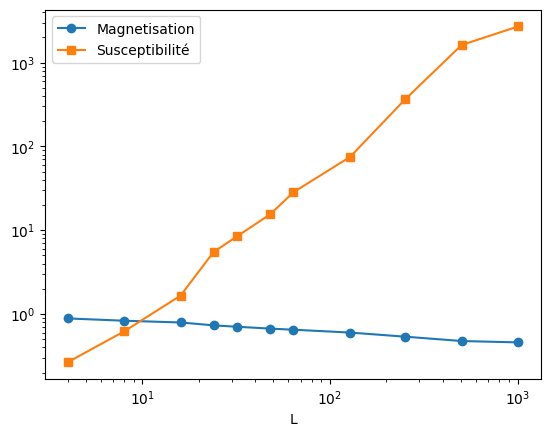

In [9]:
beta_sur_nu = -fit_exposant(L_list, M_tc)
gamma_sur_nu = fit_exposant(L_list, Chi_tc)

print("β/ν =", beta_sur_nu)
print("γ/ν =", gamma_sur_nu)

plt.figure()
plt.loglog(L_list, M_tc, 'o-', label="Magnetisation")
plt.loglog(L_list, Chi_tc, 's-', label="Susceptibilité")
plt.xlabel("L")
plt.legend()
plt.show()


β/ν = 0.12378483885357935
γ/ν = 1.7374591241160966


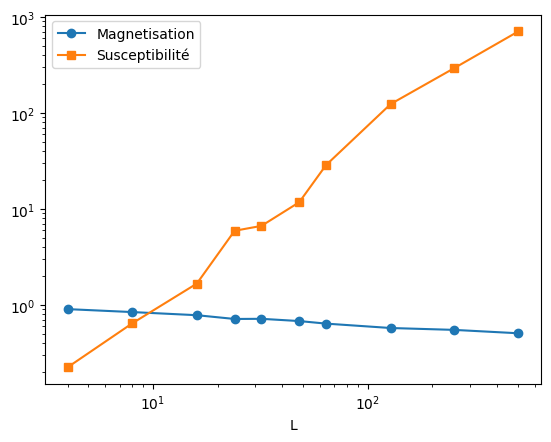

In [17]:
beta_sur_nu = -fit_exposant(L_list[0:], M_tc[0:])
gamma_sur_nu = fit_exposant(L_list[0:], Chi_tc[0:])

print("β/ν =", beta_sur_nu)
print("γ/ν =", gamma_sur_nu)

plt.figure()
plt.loglog(L_list, M_tc, 'o-', label="Magnetisation")
plt.loglog(L_list, Chi_tc, 's-', label="Susceptibilité")
plt.xlabel("L")
plt.legend()
plt.show()

## Version adaptée pour le calcul d'incertitudes par bootstrapping

In [23]:
Tc_exact = 2 / np.log(1 + np.sqrt(2))

def susceptibilite(beta, N, Msquare, Mabs):
    return (beta*N**2) * (Msquare - Mabs**2)

def capacite_calorifique(beta, N, Esquare, Emean):
    return (beta**2/N**2) * (Esquare - Emean**2)

def fit_exposant(L_list, observable):

    logL = np.log(L_list)
    logObs = np.log(observable)

    coeffs = np.polyfit(logL, logObs, 1)
    pente = coeffs[0]

    return pente

def FFS_incertitudes(L_list, nb_mesures, nb_batchs):

    E_mes = np.zeros((len(L_list), nb_mesures))
    M_mes = np.zeros((len(L_list), nb_mesures))

    for idx_L, taille in tqdm(enumerate(L_list), total=len(L_list)):
        
        
        modele = Modele_Ising(taille, energie_interaction=1, champ=0)
        beta = 1 / Tc_exact
        pas = 2*(taille**2)
        thermalisation_W(modele, beta)

        for i in range(nb_mesures):

            nb_spin_returned = 0
            while nb_spin_returned < pas :
                nb_spin_returned += Wolff_algo_etape(modele, beta)
        
            modele.E = modele.Energie()
            E_mes[idx_L][i] =modele.E
            M_mes[idx_L][i] =modele.m/(taille**2)
    
    bootstraping_batchs = np.random.choice(nb_mesures, size=(nb_batchs, nb_mesures), replace=True)

    beta_sur_nu = np.zeros(nb_batchs)
    gamma_sur_nu = np.zeros(nb_batchs)

    for b in range(nb_batchs) :
        chi_tc = np.zeros(len(L_list))
        c_tc   = np.zeros(len(L_list))
        Mabs_tc = np.zeros(len(L_list))
        for idx_L in range (len(L_list)) : 
            E_batch = E_mes[idx_L][bootstraping_batchs[b]]
            M_batch = M_mes[idx_L][bootstraping_batchs[b]]

            chi_tc[idx_L] = susceptibilite(beta, L_list[idx_L], np.mean(M_batch**2), np.mean(np.abs(M_batch)))
            c_tc[idx_L]   = capacite_calorifique(beta, L_list[idx_L], np.mean(E_batch**2), np.mean(E_batch))
            Mabs_tc[idx_L] = np.mean(np.abs(M_batch))

        beta_sur_nu[b] = -fit_exposant(L_list, Mabs_tc)
        gamma_sur_nu[b] = fit_exposant(L_list, chi_tc)

    sigma_beta = np.std(beta_sur_nu, ddof=1)
    sigma_gamma = np.std(gamma_sur_nu, ddof=1)

    Chi_mes = np.zeros(len(L_list))
    C_mes = np.zeros((len(L_list)))
    Mabs_mes = np.zeros((len(L_list)))
    for idx_L in range (len(L_list)) : 
        Chi_mes[idx_L] = susceptibilite(beta, L_list[idx_L], np.mean(M_mes[idx_L]**2), np.mean(np.abs(M_mes[idx_L])))
        C_mes[idx_L]   = capacite_calorifique(beta, L_list[idx_L], np.mean(E_mes[idx_L]**2), np.mean(E_mes[idx_L]))
        Mabs_mes[idx_L] = np.mean(np.abs(M_mes[idx_L]))
    
    beta_sur_nu_mes = -fit_exposant(L_list, Mabs_mes)
    gamma_sur_nu_mes = fit_exposant(L_list, Chi_mes)

    print("β/ν =", beta_sur_nu_mes, "±", sigma_beta)
    print("γ/ν =", gamma_sur_nu_mes, "±", sigma_gamma)

    return Chi_mes, C_mes, Mabs_mes, beta_sur_nu_mes, gamma_sur_nu_mes, sigma_beta, sigma_gamma


        



# TEST

Pas de 2 MCS

In [10]:
L=[16,32,64,128]

Chi_mes, C_mes, Mabs_mes, beta_sur_nu_mes, gamma_sur_nu_mes, sigma_beta, sigma_gamma = FFS_incertitudes(L, nb_mesures=5000, nb_batchs=1000)

100%|██████████| 4/4 [16:13<00:00, 243.32s/it]


β/ν = 0.12329850651749438 ± 0.001836658658547748
γ/ν = 1.7948256448784612 ± 0.024248284274774937


In [ ]:
L=[32,64,128,256,512]

Chi_mes, C_mes, Mabs_mes, beta_sur_nu_mes, gamma_sur_nu_mes, sigma_beta, sigma_gamma = FFS_incertitudes(L, nb_mesures=5000, nb_batchs=1000)

 80%|████████  | 4/5 [42:01<15:11, 911.82s/it]

In [12]:
L=[16,32,64,128,256,512]

Chi_mes, C_mes, Mabs_mes, beta_sur_nu_mes, gamma_sur_nu_mes, sigma_beta, sigma_gamma = FFS_incertitudes(L, nb_mesures=2000, nb_batchs=500)

100%|██████████| 6/6 [1:27:39<00:00, 876.62s/it] 

β/ν = 0.12142993855379064 ± 0.001462984249721818
γ/ν = 1.7304781543214558 ± 0.020546951078001946


Pas de 5 MCS

In [15]:
L=[4,8,16,32,64,128]

Chi_mes1, C_mes1, Mabs_mes1, beta_sur_nu_mes1, gamma_sur_nu_mes1, sigma_beta1, sigma_gamma1 = FFS_incertitudes(L, nb_mesures=10000, nb_batchs=1000)

100%|██████████| 6/6 [9:51:39<00:00, 5916.50s/it] 


β/ν = 0.11793671048764219 ± 0.0006604896836014325
γ/ν = 1.7216912301981695 ± 0.009286032518730274


In [17]:
L=[2,4,8,16,32]

Chi_mes2, C_mes2, Mabs_mes2, beta_sur_nu_mes2, gamma_sur_nu_mes2, sigma_beta2, sigma_gamma2 = FFS_incertitudes(L, nb_mesures=10000, nb_batchs=1000)

100%|██████████| 5/5 [06:46<00:00, 81.23s/it] 


β/ν = 0.11497180020538018 ± 0.000788433717431835
γ/ν = 1.9021517181608976 ± 0.019395414962662335
